# Generating embeddings using TorchGeo

## 1. Dataset organization

### Downloading the CropHarvest dataset

In [1]:
from torchgeo.datasets import CropHarvest

root = "_data"
original_dataset = CropHarvest(root=root, download=True)

In [2]:
# pandas dataframe containing label data for everything on CropHarvest
original_dataset._load_labels(root).head(5)

,type,properties.harvest_date,properties.planting_date,properties.label,properties.classification_label,properties.index,properties.is_crop,properties.lat,properties.lon,properties.dataset,properties.collection_date,properties.export_end_date,properties.externally_contributed_dataset,properties.is_test,geometry.type,geometry.coordinates,geometry
0,Feature,None,None,None,None,0,1,10.712596,37.083128,ethiopia,2020-10-22T00:00:00,2021-02-01T00:00:00,False,False,Polygon,"[[[37.0825205254332, 10.712735028397], [37.083...",NaN
1,Feature,None,None,None,None,1,1,10.724197,37.087377,ethiopia,2020-10-22T00:00:00,2021-02-01T00:00:00,False,False,Polygon,"[[[37.0872134731101, 10.7239755790256], [37.08...",NaN
2,Feature,None,None,None,None,2,1,10.713894,37.085091,ethiopia,2020-10-22T00:00:00,2021-02-01T00:00:00,False,False,Polygon,"[[[37.0849835772546, 10.7137105808623], [37.08...",NaN
3,Feature,None,None,None,None,3,1,10.713338,37.090290,ethiopia,2020-10-22T00:00:00,2021-02-01T00:00:00,False,False,Polygon,"[[[37.0902073888884, 10.7132048338664], [37.09...",NaN
4,Feature,None,None,None,None,4,1,10.721858,37.083121,ethiopia,2020-10-22T00:00:00,2021-02-01T00:00:00,False,False,Polygon,"[[[37.0830703114103, 10.7215953100434], [37.08...",NaN


### Exploring the dataset

In [3]:
# under properties.dataset we can find the names of the "sub datasets" inside CropHarvest
original_dataset_counts = original_dataset.labels['properties.dataset'].value_counts()

#  all the subdataset inside the CropHarvest dataset and the number of its samples
print("Sub-datasets inside CropHarvest:")
print(original_dataset_counts)

Sub-datasets inside CropHarvest:
properties.dataset
geowiki-landcover-2017          35866
croplands                       14976
canada                           9088
ile-de-france                    6184
central-asia                     5302
rwanda-ceo                       3600
reunion-france                   2776
kenya-non-crop                   2704
germany                          2550
martinique-france                2421
tanzania-ceo                     2400
mali-helmets-labelling-crops     1506
togo                             1276
lem-brazil                        860
ethiopia                          830
tanzania-rice-ecaas               800
sudan                             422
tanzania                          392
kenya                             319
togo-eval                         306
uganda                            233
mali                              148
mali-non-crop                     142
zimbabwe                           49
brazil-non-crop                    3

In [4]:
# group by the sub dataset name and look at the 'properties.label' column, which contains the crop type names
# if it is binary it will be None
# if it is multiclass it will have the crop type names

original_dataset_class_search = original_dataset.labels.groupby('properties.dataset')['properties.label'].unique()

binary = []
multiclass = []

for sub_dataset, labels in original_dataset_class_search.items():
    labels = [l for l in labels if l is not None and not (isinstance(l, float))]

    if len(labels) > 0:
        multiclass.append((sub_dataset, labels))
    else:
        binary.append(sub_dataset)

print("Binary sub-datasets:")
for i in binary:
    print(i)

print("\nMulticlass sub-datasets:")
for j in multiclass:
    print(j)

Binary sub-datasets:
brazil-non-crop
ethiopia
geowiki-landcover-2017
kenya-non-crop
mali-non-crop
rwanda-ceo
sudan
tanzania-ceo
togo
togo-eval

Multiclass sub-datasets:
('canada', ['wetland', 'abandoned (overgrown)', 'urban', 'shrubland', 'mixed forage', 'pasture (undiff)', 'sod', 'cereals (undiff)', 'barley (undiff)', 'corn', 'timothy', 'alfalfa', 'spring wheat', 'soybeans', 'forest', 'nursery', 'winter barley', 'canola/rapeseed', 'winter wheat', 'unimproved pasture', 'christmas trees', 'greenhouse', 'winter rye', 'pasture/forage', 'red clover', 'abandoned (shrubs)', 'other', 'fallow', 'native grassland', 'barren', 'water', 'oats', 'coniferous', 'white clover', 'broadleaf', 'clover (undiff)', 'sunflowers', 'greenfeed (mixed)', 'beans (undiff)', 'melon', 'apples', 'vegetables (undiff)', 'raspberry', 'fruits (berry & annual)', 'strawberry', 'onions', 'potatoes', 'broccoli', 'cauliflower', 'peas (undiff)', 'field peas', 'sugarbeets', 'ginseng', 'rye (undiff)', 'cherries', 'cucumber', 'to

### Isolate *geowiki-landcover-2017* sub dataset


We want to work with an isolated sub-set, binary, and preferably with lots of samples. For that reason it is wise to choose *geowiki-landcover-2017*
- **Sub dataset name:** *geowiki-landcover-2017*
- **Sample Count:** 35866 points
- **Format:** pixel-level time series

In [5]:
from torch.utils.data import Subset

# finding all the entries on original_dataset that has properties.dataset equal to 'geowiki-landcover-2017'
DATASET_NAME = 'geowiki-landcover-2017'
geowiki_indices = original_dataset.labels.index[original_dataset.labels['properties.dataset'] == DATASET_NAME].tolist()

# create the isolated dataset
geowiki_dataset = Subset(original_dataset, geowiki_indices)

print(f"Original dataset size: {len(original_dataset)}")
print(f"Isolated dataset size: {len(geowiki_dataset)}")

Original dataset size: 70213
Isolated dataset size: 35866


In [6]:
geowiki_dataset.__getitem__(35865)

{'array': tensor([[-8.6492e+00, -1.6924e+01,  1.1490e+03,  9.6500e+02,  1.0280e+03,
           9.1800e+02,  1.2750e+03,  1.4320e+03,  1.5970e+03,  1.6940e+03,
           5.9700e+02,  1.5540e+03,  9.2200e+02,  2.7950e+02,  1.3488e-03,
           1.0000e+02,  2.7803e+00,  1.9483e-01],
         [-1.0193e+01, -1.5457e+01,  1.1420e+03,  1.0330e+03,  1.0880e+03,
           1.1390e+03,  1.5460e+03,  1.8210e+03,  1.9780e+03,  1.9430e+03,
           9.6000e+02,  2.0750e+03,  1.4660e+03,  2.8163e+02,  2.3801e-03,
           1.0000e+02,  2.7803e+00,  2.7610e-01],
         [-9.1937e+00, -1.8748e+01,  1.0000e+03,  9.5000e+02,  7.8300e+02,
           1.0920e+03,  2.9070e+03,  3.4030e+03,  3.2140e+03,  3.7180e+03,
           1.7470e+03,  1.4770e+03,  7.4400e+02,  2.8380e+02,  1.1336e-03,
           1.0000e+02,  2.7803e+00,  5.6352e-01],
         [-9.6921e+00, -1.6796e+01,  1.1580e+03,  1.2110e+03,  1.1860e+03,
           1.3020e+03,  3.5000e+03,  4.6690e+03,  4.1930e+03,  5.0670e+03,
           1.084

### Turning *geowiki-landcover-2017* into a binary dataset

But we can see that, even though the sub dataset *geowiki-landcover-2017* is binary and has no `properties.label` associated with, there are many possible values for the label, meaning that has in fact is a multi classes.

For that reason we'll apply a transformation on the label tensor, making sure that all 0 label values remain 0 (non crop) and that any other value is turned into 1 (crop).

In [7]:
import torch

class BinaryDatasetWrapper(torch.utils.data.Dataset):
    def __init__(self, subset):
        self.subset = subset

    def __getitem__(self, index):
        sample = self.subset[index]
        
        sample['label'] = torch.tensor(1) if sample['label'] > 0 else torch.tensor(0)
        return sample

    def __len__(self):
        return len(self.subset)

dataset = BinaryDatasetWrapper(geowiki_dataset)

In [8]:
print("Original geowiki dataset:")
print(geowiki_dataset[45]['label'])
print(geowiki_dataset[35865]['label'])
print(geowiki_dataset[0]['label'])

print("\nBinary geowiki dataset:")
print(dataset[45]['label'])
print(dataset[35865]['label'])
print(dataset[0]['label'])

Original geowiki dataset:
tensor(62)
tensor(74)
tensor(0)

Binary geowiki dataset:
tensor(1)
tensor(1)
tensor(0)


## 2. *geowiki-landcover-2017* data exploration

### Data structure

Each data point represents a single geographic location over a full calendar year. Each sample is provided as a $12 \times 18$ tensor:
- Rows (12): Represent the **12 monthsof the year (temporal dimension)
- Columns (18): Represent the spectral and environmental bands (feature dimension)

The data combines multiple sensors and environmental variables:

| Band Index | Feature Category | Description |
| :--- | :--- | :--- |
| **0 - 12** | **Sentinel-2 (Optical)** | Multi-spectral bands including RGB, NIR, and Red-Edge |
| **13 - 14** | **Sentinel-1 (Radar)** | VV and VH polarizations (crucial for cloud-penetrating growth monitoring) |
| **15** | **ERA5 (Temp)** | 2-meter temperature data (average monthly) |
| **16** | **ERA5 (Precip)** | Total monthly precipitation |
| **17** | **SRTM (Elevation)** | Digital Elevation Model (Static value repeated across time steps) |

In [57]:
original_dataset.all_bands

('VV',
 'VH',
 'B2',
 'B3',
 'B4',
 'B5',
 'B6',
 'B7',
 'B8',
 'B8A',
 'B9',
 'B11',
 'B12',
 'temperature_2m',
 'total_precipitation',
 'elevation',
 'slope',
 'NDVI')

In [9]:
dataset[0].keys()

dict_keys(['array', 'label'])

In [10]:
sample = dataset.__getitem__(45)
sample

{'array': tensor([[-1.0183e+01, -1.6566e+01,  9.3800e+02,  9.0100e+02,  5.9700e+02,
           1.2080e+03,  2.9380e+03,  3.6900e+03,  3.6430e+03,  4.2700e+03,
           8.0900e+02,  2.0260e+03,  8.2300e+02,  2.9821e+02,  9.8020e-04,
           7.0000e+01,  1.4335e+01,  6.0749e-01],
         [-1.0203e+01, -1.6600e+01,  1.0630e+03,  1.0640e+03,  8.4000e+02,
           1.4110e+03,  3.1460e+03,  3.8450e+03,  3.7380e+03,  4.4200e+03,
           9.2800e+02,  2.5260e+03,  1.1220e+03,  2.9834e+02,  1.2267e-03,
           7.0000e+01,  1.4335e+01,  5.6651e-01],
         [-1.1426e+01, -1.7332e+01,  1.0220e+03,  1.0280e+03,  8.2400e+02,
           1.3910e+03,  2.6530e+03,  3.2970e+03,  3.2920e+03,  3.8130e+03,
           7.5800e+02,  2.5200e+03,  1.2310e+03,  2.9867e+02,  1.2883e-03,
           7.0000e+01,  1.4335e+01,  5.2462e-01],
         [-1.2394e+01, -1.6972e+01,  1.1210e+03,  1.1690e+03,  8.2300e+02,
           1.3900e+03,  3.2320e+03,  4.2390e+03,  3.9820e+03,  4.8650e+03,
           4.580

In [11]:
sample['array'].shape # data itself

torch.Size([12, 18])

In [12]:
sample['label'].shape # binary label

torch.Size([])

### Data visualization

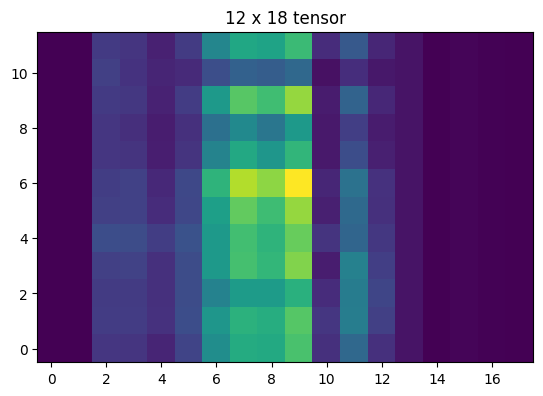

In [13]:
import matplotlib.pyplot as plt

# the actual tensor
plt.imshow(sample['array'], origin='lower')
plt.title("12 x 18 tensor")
plt.show()

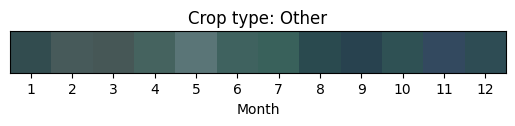

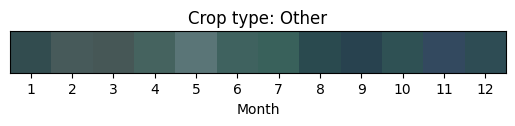

In [14]:
# it shows two plots because it is prepared to plot ground-truth and 
# it combines the rgb channels into a single pixel 
original_dataset.plot(sample)

In [15]:
# # load the crop-type label for a single pixel time series
# original_dataset._load_label(45, dataset='geowiki-landcover-2017')

# para ver depois porque é que isto acontece

In [16]:
def get_class_balance(subset_obj):
    if not hasattr(subset_obj, 'indices'):
        indices = range(len(subset_obj))
    else:
        indices = subset_obj.indices

    curr = subset_obj
    while not hasattr(curr, 'labels'):
        if hasattr(curr, 'dataset'):
            curr = curr.dataset
        elif hasattr(curr, 'subset'):
            curr = curr.subset
        else:
            break
    
    if hasattr(curr, 'labels'):
        labels = curr.labels.iloc[indices]['properties.is_crop']
        counts = labels.value_counts().to_dict()
        
        crop_count = counts.get(1, 0)
        non_crop_count = counts.get(0, 0)
        total = len(indices)
        
        print(f"Total Samples: {total}")
        print(f"  - Crop (1):     {crop_count} ({100*crop_count/total:.1f}%)")
        print(f"  - Non-Crop (0): {non_crop_count} ({100*non_crop_count/total:.1f}%)")
        return counts
    else:
        print("Error: Could not find labels in the dataset hierarchy.")
        return None

In [17]:
get_class_balance(dataset)

Total Samples: 35866
  - Crop (1):     18604 (51.9%)
  - Non-Crop (0): 17262 (48.1%)


{1: 18604, 0: 17262}

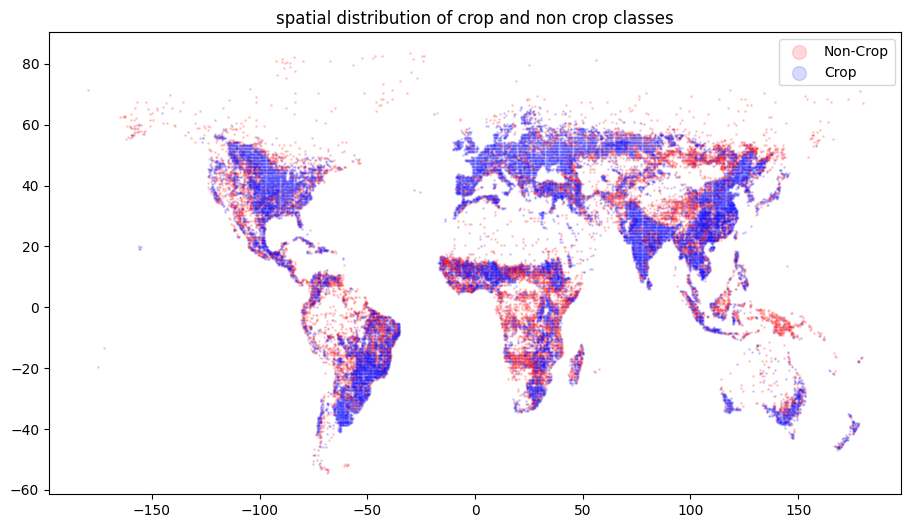

In [18]:
plt.figure(figsize=(11, 6))

geowiki_metadata = original_dataset.labels.iloc[geowiki_indices]

for is_crop, color, label in [(0, 'red', 'Non-Crop'), (1, 'blue', 'Crop')]:
    mask = geowiki_metadata['properties.is_crop'] == is_crop
    subset = geowiki_metadata[mask]
    plt.scatter(subset['properties.lon'], subset['properties.lat'], s=1, alpha=0.15, c=color, label=label)

plt.legend(markerscale=10)
plt.title("spatial distribution of crop and non crop classes")
plt.show()

## 3. Creating the embeddings model

### Train/test split

In [19]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

print("Train set size:", len(train_dataset))
print("Test set size:", len(test_dataset))

Train set size: 28692
Test set size: 7174


In [20]:
# class balance in train set
get_class_balance(train_dataset)

Total Samples: 28692
  - Crop (1):     14930 (52.0%)
  - Non-Crop (0): 13762 (48.0%)


{1: 14930, 0: 13762}

In [21]:
# class balance in test set
get_class_balance(test_dataset)

Total Samples: 7174
  - Crop (1):     3674 (51.2%)
  - Non-Crop (0): 3500 (48.8%)


{1: 3674, 0: 3500}

### DOFA model

Instead of trying to retrain the whole DOFA model (which is huge and requires a lot of GPU memory), we will use DOFA as a "frozen" backbone to generate embeddings and train a simple, fast classifier on top.

In [ ]:
import lightning as L
from torch.utils.data import DataLoader

class GeoWikiDataModule(L.LightningDataModule):
    def __init__(self, train_ds, test_ds, batch_size: int = 32, num_workers: int = 0):
        super().__init__()
        self.train_ds = train_ds
        self.test_ds = test_ds
        self.batch_size = batch_size
        self.num_workers = num_workers

    def train_dataloader(self):
        return DataLoader(
            self.train_ds, 
            batch_size=self.batch_size, 
            shuffle=False, 
            num_workers=self.num_workers
        )

    def val_dataloader(self):
        return DataLoader(
            self.test_ds, 
            batch_size=self.batch_size, 
            num_workers=self.num_workers
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_ds, 
            batch_size=self.batch_size, 
            shuffle=False,
            num_workers=self.num_workers
        )

In [23]:
# loading data
dm = GeoWikiDataModule(train_dataset, test_dataset, batch_size=64)
train_loader = dm.train_dataloader()
test_loader = dm.test_dataloader()

In [24]:
import torch
from torch.utils.data import DataLoader

# define device to use, cuda, cpu or mps (our case with mac)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps") # For Mac users
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [25]:
from torchgeo.models import DOFABase16_Weights, get_model

model = get_model('dofa_base_patch16_224', weights=DOFABase16_Weights.DOFA_MAE)
model = model.eval()

/Users/devseed/Documents/repos/embeddings_in_TorchGeo/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm

def embed_dofa(model, dataloader, device):
    model.eval()
    model.to(device)
    x_all, y_all = [] , []
    
    wavelengths = [60.0, 60.0, 490.0, 560.0, 665.0, 842.0, 1610.0, 2190.0, 
                   865.0, 705.0, 740.0, 783.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

    for batch in tqdm(dataloader):
        x = batch['array'].to(torch.float32).to(device) 
        y = batch['label']

        # why doing this?!
        x = x.permute(0, 2, 1) 
        # and why doing this?!
        x = x.unsqueeze(-1)
        # also why doing this?!
        x = F.pad(x, (0, 15, 0, 4)) 

        with torch.inference_mode():
            features = model.forward_features(x, wavelengths=wavelengths)
            
            # why doing this?!
            if features.ndim == 3:
                # why doing this?!
                embeddings = features.mean(dim=1) 
            else:
                embeddings = features

        x_all.append(embeddings.cpu().numpy())
        y_all.append(y.numpy())

    return np.concatenate(x_all, axis=0), np.concatenate(y_all, axis=0)

In [27]:
# ensure that is running on mps or chosen device
model = model.to(device) 

print("Extracting training embeddings...")
x_train, y_train = embed_dofa(model, train_loader, device)

print("Extracting test embeddings...")
x_test, y_test = embed_dofa(model, test_loader, device)

print(f"Corrected! Created {x_train.shape[0]} vectors of size {x_train.shape[1]}")

Extracting training embeddings...


100%|██████████| 449/449 [34:52<00:00,  4.66s/it]


Extracting test embeddings...


100%|██████████| 113/113 [08:54<00:00,  4.73s/it]

Corrected! Created 28692 vectors of size 768


In [28]:
output_folder = "_results/"

# save the embeddings
np.save(f'{output_folder}x_train_dofa.npy', x_train)
np.save(f'{output_folder}y_train_dofa.npy', y_train)
np.save(f'{output_folder}x_test_dofa.npy', x_test)
np.save(f'{output_folder}y_test_dofa.npy', y_test)

print("Files saved successfully!")

Files saved successfully!


## Analysing the results

### Simple classifier

In [29]:
import numpy as np

x_train = np.load('_results/x_train_dofa.npy')
y_train = np.load('_results/y_train_dofa.npy')

x_test = np.load('_results/x_test_dofa.npy')
y_test = np.load('_results/y_test_dofa.npy')

In [30]:
# # verify with dummy logistic regression

# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import cross_val_score

# clf = LogisticRegression(max_iter=2000)
# scores = cross_val_score(clf, x_train, y_train, cv=5)

# print(scores.mean())

In [31]:
# verify with random forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# training
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=1998)
rf.fit(x_train, y_train)

# predicting
y_pred = rf.predict(x_test)

# evaluating
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 0.801
              precision    recall  f1-score   support

           0       0.75      0.59      0.66      2354
           1       0.82      0.90      0.86      4820

    accuracy                           0.80      7174
   macro avg       0.78      0.75      0.76      7174
weighted avg       0.80      0.80      0.79      7174



In [32]:
# seeing the training embeddings
x_train

array([[-0.6843597 ,  1.3317857 , -0.1730215 , ..., -1.0050291 ,
         1.4445201 ,  0.16924465],
       [-0.7558303 ,  1.3373078 , -0.12454218, ..., -0.938168  ,
         1.5349168 ,  0.27727735],
       [-0.6637167 ,  1.2818854 , -0.00314577, ..., -1.0425191 ,
         1.4366606 ,  0.49263978],
       ...,
       [-0.6163079 ,  0.46319622, -0.065437  , ..., -0.88993376,
         1.6282924 ,  0.20553823],
       [-0.73618203,  0.5652616 , -0.11604235, ..., -1.0232474 ,
         1.1033449 ,  0.39190474],
       [-0.9262897 ,  0.5352571 , -0.07066359, ..., -1.1458124 ,
         0.8557055 ,  0.52568597]], shape=(28692, 768), dtype=float32)

### Embeddings visualization

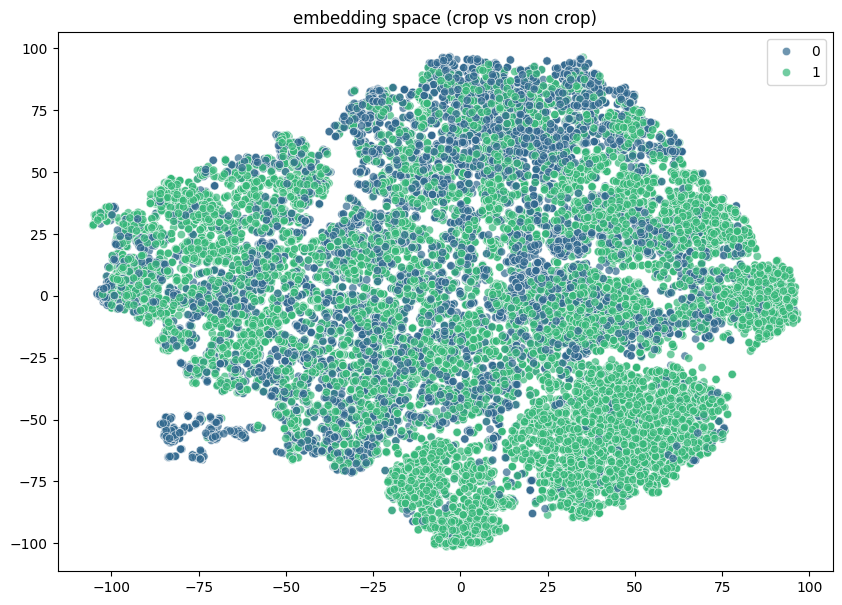

In [33]:
from sklearn.manifold import TSNE
import seaborn as sns

tsne = TSNE(n_components=2, random_state=1998)
x_2d = tsne.fit_transform(x_train)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=x_2d[:,0], y=x_2d[:,1], hue=y_train, palette='viridis', alpha=0.7)
plt.title("embedding space (crop vs non crop)")
plt.show()

### Spatial correlation of the embeddings

In [37]:
# Check if the label from the dataset matches the label in our y_train
sample_idx = 100
dataset_label = train_dataset[sample_idx]['label']
extracted_label = y_train[sample_idx]

print(f"Dataset Label: {dataset_label}, Extracted Label: {extracted_label}")
# If these match, your coordinates are perfectly aligned!

Dataset Label: 1, Extracted Label: 1


In [65]:
import re

def get_coordinates_from_files(train_or_test_subset):
    # 1. Drill down to the original TorchGeo CropHarvest object
    wrapper = train_or_test_subset.dataset
    inner_subset = wrapper.subset
    original_ds = inner_subset.dataset
    
    # 2. Get the list of file paths
    all_files = original_ds.files
    
    # 3. Get the mapping of indices
    outer_indices = train_or_test_subset.indices
    inner_indices = inner_subset.indices
    
    lats, lons = [], []
    
    # Regex to find numbers after 'lat' and 'lon' in the file string
    # This works for formats like "lat_0.5_lon_10.2" or "0.5_10.2"
    for outer_idx in tqdm(outer_indices, desc="Parsing Filenames"):
        actual_original_idx = inner_indices[outer_idx]
        file_path = all_files[actual_original_idx]
        
        # We search for the pattern of the coordinate in the string
        # Most CropHarvest file structures use: .../index_lat_lon/
        try:
            # Look for numbers (including negatives and decimals)
            parts = re.findall(r"[-+]?\d*\.\d+|\d+", file_path)
            # Usually the last two or specific indices are lat/lon
            # Adjusting to standard CropHarvest folder naming:
            lats.append(float(parts[-2]))
            lons.append(float(parts[-1]))
        except:
            # If regex fails, we print one path to see the format
            if outer_idx == outer_indices[0]:
                print(f"DEBUG: File path format is: {file_path}")
            lats.append(0.0)
            lons.append(0.0)
            
    return np.column_stack((lats, lons))

# Run the parser
coords_train = get_coordinates_from_files(train_dataset)
coords_test = get_coordinates_from_files(test_dataset)

Parsing Filenames: 100%|██████████| 28692/28692 [00:00<00:00, 579020.16it/s]


DEBUG: File path format is: {'chip': '_data/features/arrays/22189_geowiki-landcover-2017.h5', 'index': '22189', 'dataset': 'geowiki-landcover-2017'}


Parsing Filenames: 100%|██████████| 7174/7174 [00:00<00:00, 715388.05it/s]

DEBUG: File path format is: {'chip': '_data/features/arrays/28956_geowiki-landcover-2017.h5', 'index': '28956', 'dataset': 'geowiki-landcover-2017'}


In [66]:
coords_test

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       ...,
       [0., 0.],
       [0., 0.],
       [0., 0.]], shape=(7174, 2))